# 🌍 RiverScope: Foundation Model Training
This notebook orchestrates your end-to-end training pipeline. It brings together your `RiverScopeDataset`, the frozen `OlmoEarth` foundation model, your custom CNN probing head, and the custom training loop into a single interactive playground!


In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"  # <--- MUST BE SET BEFORE IMPORTING TORCH
import os
import torch
from torch.utils.data import DataLoader, random_split
from huggingface_hub import snapshot_download
from olmoearth_pretrain.model_loader import load_model_from_id

# Let python know about your external absolute paths
import sys
sys.path.append('../')

from data.dataset import RiverScopeDataset
from src.models.probing import EndToEndOlmoSegmenter
from src.training.trainer import RiverScopeTrainer


/Users/danny/miniconda3/envs/riverscope_env/lib/python3.11/site-packages/olmoearth_pretrain/model_loader.py:38: UserWarning: olmo-core not installed. Running in inference-only mode. For training: pip install olmoearth-pretrain[training]
  from olmoearth_pretrain.config import Config


In [3]:
# 1. SETUP DATASET & DATALOADERS
DATA_ROOT = "../data/raw/RiverScope_dataset" 
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")

print("Initializing RiverScopeDataset...")
full_dataset = RiverScopeDataset(csv_file=TRAIN_CSV, data_root=DATA_ROOT)

# Split 80/20 for Train/Validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print(f"Train Set Size: {len(train_dataset)}")
print(f"Validation Set Size: {len(val_dataset)}")

# Memory-constrained batch loading: Start with 2-4 for Mac MPS GPU limit!
BATCH_SIZE = 4
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


Initializing RiverScopeDataset...
Train Set Size: 629
Validation Set Size: 158


In [4]:
# 2. LOAD OLMOEARTH & SEGMENTATION HEAD
model_repo = "allenai/OlmoEarth-v1-Base"
print(f"Loading {model_repo} from HuggingFace cache...")

local_dir = snapshot_download(repo_id=model_repo)
foundation_model = load_model_from_id(local_dir, load_weights=True)

# Wrap the frozen Foundation Model with our Tunable Decoder
print("Attaching 16x upsampling Probing Head...")
model = EndToEndOlmoSegmenter(foundation_model=foundation_model, embed_dim=768, num_classes=1)

print("✅ Model Architecture Assembled.")


Loading allenai/OlmoEarth-v1-Base from HuggingFace cache...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/danny/miniconda3/envs/riverscope_env/lib/python3.11/importlib/__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


Attaching 16x upsampling Probing Head...
✅ Model Architecture Assembled.


In [4]:
import os
# This forces PyTorch to gracefully fallback to CPU for the single missing interpolation op,
# while keeping the rest of your heavy training loop accelerated on the M4 GPU!
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"


In [6]:
# 3. INITIALIZE TRAINER & FIRE RUN
print("Initializing Custom RiverScope Trainer...")
trainer = RiverScopeTrainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    lr=1e-4
)

Initializing Custom RiverScope Trainer...


In [ ]:
# Start Fine-Tuning the Probe!
# The absolute best weights (tracked via Val-IoU) will automatically save to 'best_olmo_probe.pth'
best_iou = trainer.fit(epochs=5, save_path='best_olmo_probe.pth')


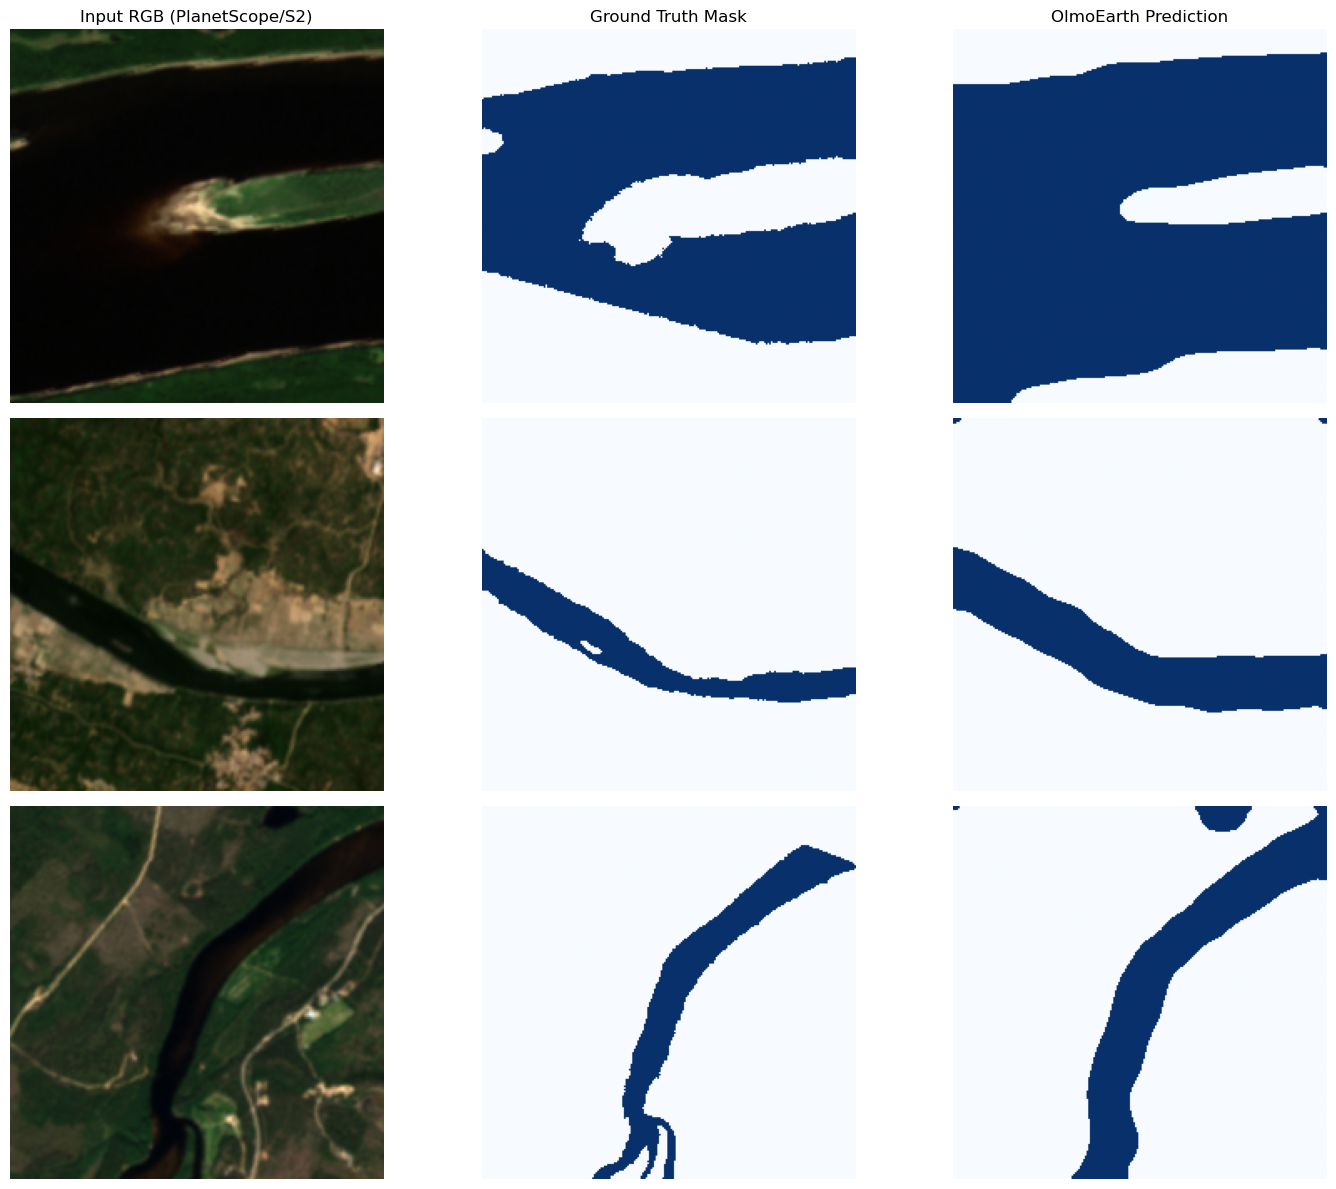

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 5. VISUAL INFERENCE
# Load the absolute best weights back into the model
model.load_state_dict(torch.load('best_olmo_probe.pth', map_location=trainer.device, weights_only=True))
model.eval()

# Grab a single batch from the unseen validation loader
images, masks = next(iter(val_loader))
images, masks = images.to(trainer.device), masks.to(trainer.device)

# Force the MPS Math Backend fallback again for inference
from torch.nn.attention import sdpa_kernel, SDPBackend
with torch.no_grad(), sdpa_kernel(SDPBackend.MATH):
    logits = model(images)
    
# Convert raw logic scores into a binary mask map (Threshold = 0.5)
predictions = (torch.sigmoid(logits) > 0.5).float()

# Move tensors to CPU for Matplotlib
images_cpu = images.cpu()
masks_cpu = masks.cpu().squeeze()
preds_cpu = predictions.cpu().squeeze()

# Plot the first 3 samples in the batch
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs[0, 0].set_title("Input RGB (PlanetScope/S2)")
axs[0, 1].set_title("Ground Truth Mask")
axs[0, 2].set_title("OlmoEarth Prediction")

for i in range(min(3, len(images_cpu))):
    # Extract RGB bands. (In our S2 mapping: Red=Index 3, Green=Index 2, Blue=Index 1)
    # The '0' drops the dummy Time dimension, allowing [3, 2, 1] to hit the 12 Channels!
    rgb = images_cpu[i, 0, [3, 2, 1], :, :].permute(1, 2, 0).numpy()
    
    # Normalize RGB for clean plotting bounded 0-1
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    
    axs[i, 0].imshow(rgb)
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(masks_cpu[i], cmap='Blues', vmin=0, vmax=1)
    axs[i, 1].axis('off')
    
    axs[i, 2].imshow(preds_cpu[i], cmap='Blues', vmin=0, vmax=1)
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()


In [11]:
# 4. FULL SCALE-UP RUN (25 Epochs)
print("Initiating full training sweep...")
trainer.optimizer.lr = 5e-5  # Drop learning rate slightly for finer convergence on longer runs

# Train for 25 epochs - you can safely step away while this cranks!
best_iou = trainer.fit(epochs=25, save_path='best_olmo_probe_full.pth')
print(f"Sweep complete! Max validation IoU reached: {best_iou:.4f}")


Initiating full training sweep...
Starting Training on device: mps...
\n[Epoch 1/25]


Validation: 100%|██████████| 40/40 [00:13<00:00,  3.02it/s]


Train Loss: 2.1865 | Train IoU: 0.4197
Val Loss:   1.9084 | Val IoU:   0.4620
✅ Checkpoint hit! New best model saved with IoU: 0.4620
\n[Epoch 2/25]


Validation: 100%|██████████| 40/40 [00:13<00:00,  3.02it/s]


Train Loss: 2.0367 | Train IoU: 0.4220
Val Loss:   1.8109 | Val IoU:   0.4137
\n[Epoch 3/25]


...

Train Loss: 1.8239 | Train IoU: 0.4277
Val Loss:   1.7490 | Val IoU:   0.4057
\n[Epoch 24/25]


Validation: 100%|██████████| 40/40 [00:13<00:00,  3.02it/s]


Train Loss: 1.8458 | Train IoU: 0.4213
Val Loss:   1.6593 | Val IoU:   0.4819
\n[Epoch 25/25]


Validation: 100%|██████████| 40/40 [00:13<00:00,  3.02it/s]

Train Loss: 1.7613 | Train IoU: 0.4331
Val Loss:   1.6771 | Val IoU:   0.4603
Sweep complete! Max validation IoU reached: 0.5020


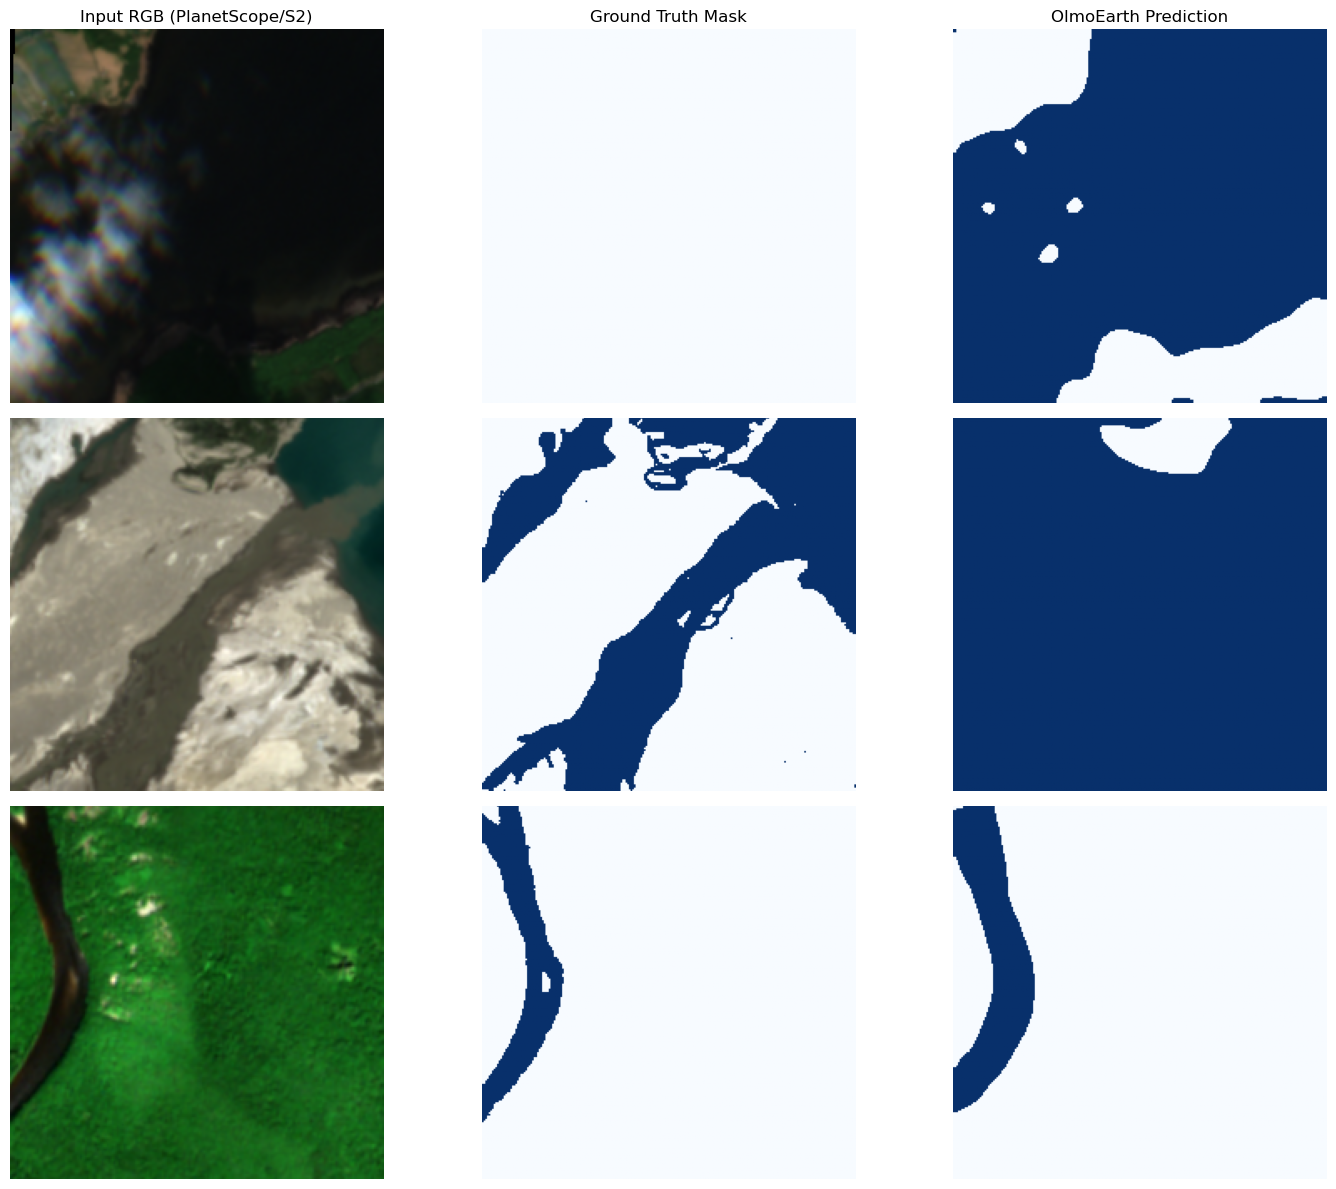

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 5. VISUAL INFERENCE
# Load the absolute best weights back into the model
model.load_state_dict(torch.load('best_olmo_probe_full.pth', map_location=trainer.device, weights_only=True))
model.eval()

# Grab a single batch from the unseen validation loader
# Grab 3 totally random samples from the untouched validation set!
vis_loader = DataLoader(val_dataset, batch_size=3, shuffle=True)
images, masks = next(iter(vis_loader))

images, masks = images.to(trainer.device), masks.to(trainer.device)


# Force the MPS Math Backend fallback again for inference
from torch.nn.attention import sdpa_kernel, SDPBackend
with torch.no_grad(), sdpa_kernel(SDPBackend.MATH):
    logits = model(images)
    
# Convert raw logic scores into a binary mask map (Threshold = 0.5)
predictions = (torch.sigmoid(logits) > 0.5).float()

# Move tensors to CPU for Matplotlib
images_cpu = images.cpu()
masks_cpu = masks.cpu().squeeze()
preds_cpu = predictions.cpu().squeeze()

# Plot the first 3 samples in the batch
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs[0, 0].set_title("Input RGB (PlanetScope/S2)")
axs[0, 1].set_title("Ground Truth Mask")
axs[0, 2].set_title("OlmoEarth Prediction")

for i in range(min(3, len(images_cpu))):
    # Extract RGB bands. (In our S2 mapping: Red=Index 3, Green=Index 2, Blue=Index 1)
    # The '0' drops the dummy Time dimension, allowing [3, 2, 1] to hit the 12 Channels!
    rgb = images_cpu[i, 0, [3, 2, 1], :, :].permute(1, 2, 0).numpy()
    
    # Normalize RGB for clean plotting bounded 0-1
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    
    axs[i, 0].imshow(rgb)
    axs[i, 0].axis('off')
    
    axs[i, 1].imshow(masks_cpu[i], cmap='Blues', vmin=0, vmax=1)
    axs[i, 1].axis('off')
    
    axs[i, 2].imshow(preds_cpu[i], cmap='Blues', vmin=0, vmax=1)
    axs[i, 2].axis('off')

plt.tight_layout()
plt.show()
